# Visualization
Loads the pre-computed results from `analysis_results.pkl` (produced by `01_analysis.ipynb`) and renders all charts.

Run `01_analysis.ipynb` at least once before this notebook.

In [18]:
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [19]:
# ── Load Analysis Results ───────────────────────────────────────────────────────
with open('analysis_results.pkl', 'rb') as f:
    results = pickle.load(f)

df = results['df']
filter_label = results['filter_label']
status_counts = results['status_counts']
noshow_by_division = results['noshow_by_division']
specialty_demand = results['specialty_demand']
specialty_wait = results['specialty_wait']
header_label = results['header_label']
age_dist = results['age_dist']
monthly_trend = results['monthly_trend']
print(f"Loaded analysis results — filter: {filter_label}")
display(specialty_demand)


Loaded analysis results — filter: Cardiologist


,group,appointments_count
0,Dhaka,28
1,Chattogram,14
2,Khulna,12
3,Rajshahi,8
4,Mymensingh,7
5,Rangpur,6
6,Barishal,5
7,Sylhet,5


Chart saved as healthcare_analysis.png


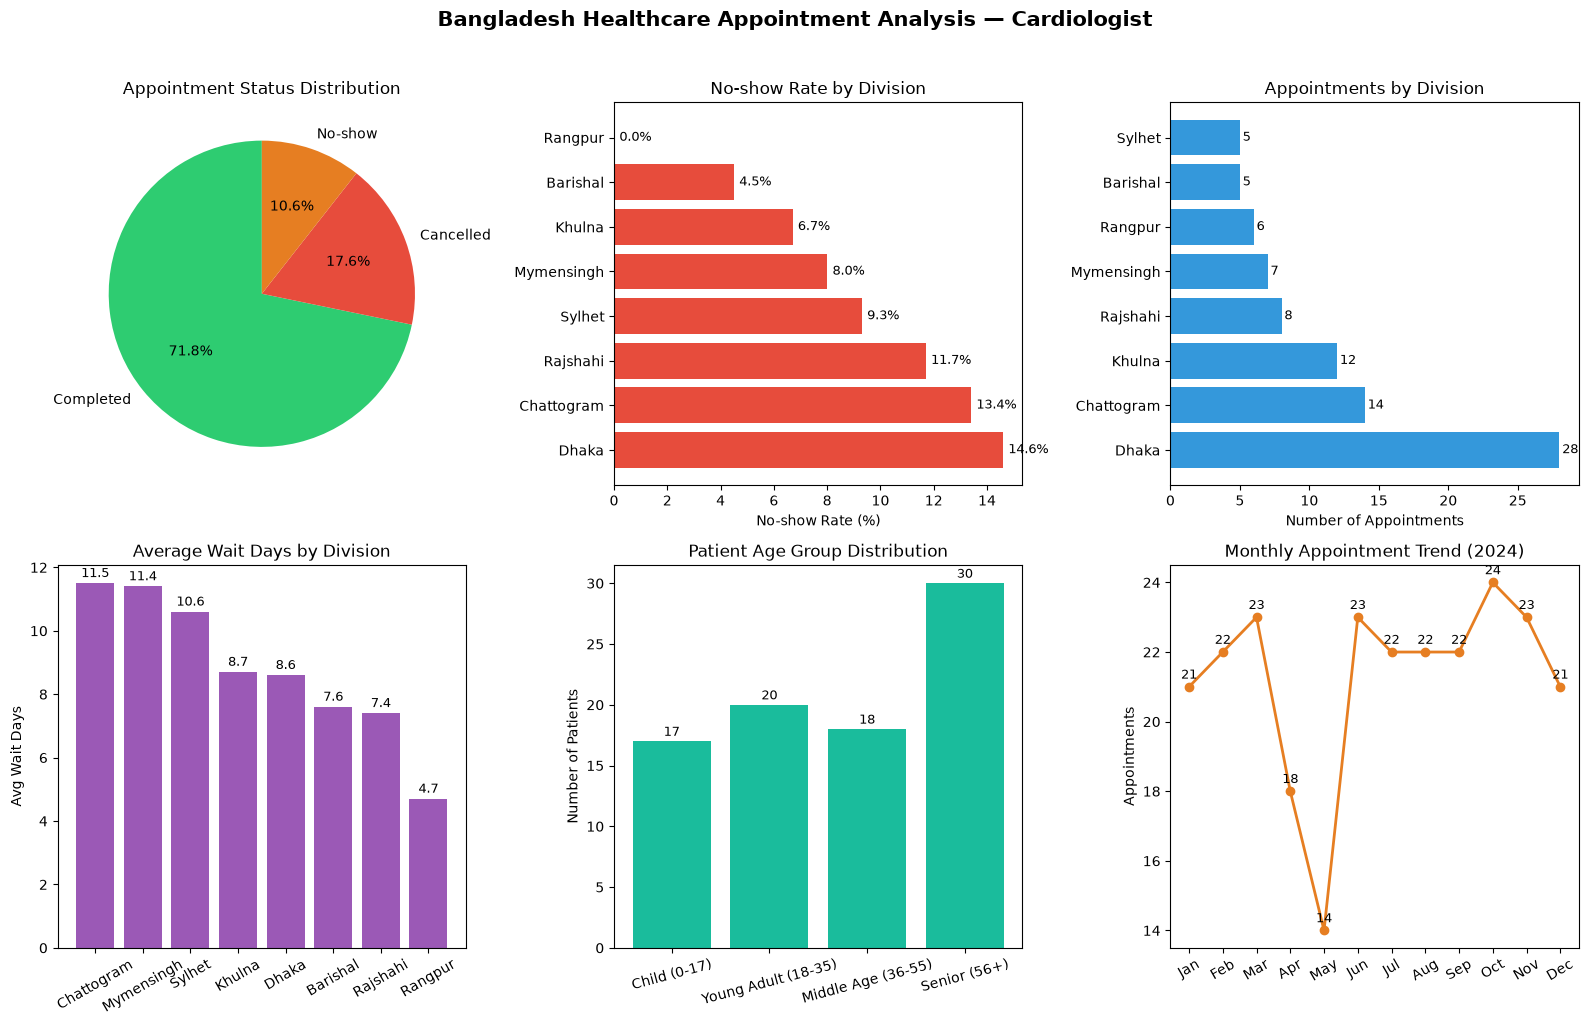

In [20]:
# ── Visualizations ─────────────────────────────────────────────────────────────
plt.close('all')  # clears out any old figures before drawing a new one

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f'Bangladesh Healthcare Appointment Analysis — {filter_label}', fontsize=15, fontweight='bold', y=1.02)

colors_main = ['#2ecc71', '#e74c3c', '#e67e22']
bar_color = '#3498db'

def _no_data(ax, title):
    ax.text(0.5, 0.5, 'No data for this filter', ha='center', va='center', fontsize=10, color='gray')
    ax.set_title(title)
    ax.axis('off')

# Plot 1 — Appointment Status
if len(status_counts) == 0:
    _no_data(axes[0, 0], 'Appointment Status Distribution')
else:
    axes[0, 0].pie(
        status_counts.values,
        labels=status_counts.index,
        autopct='%1.1f%%',
        colors=colors_main[:len(status_counts)],
        startangle=90
    )
    axes[0, 0].set_title('Appointment Status Distribution')

# Plot 2 — No-show Rate by Division
if noshow_by_division.empty:
    _no_data(axes[0, 1], 'No-show Rate by Division')
else:
    axes[0, 1].barh(
        noshow_by_division['division'],
        noshow_by_division['noshow_rate_pct'],
        color='#e74c3c'
    )
    axes[0, 1].set_xlabel('No-show Rate (%)')
    # Only one division left after filtering? Say so instead of a misleading title.
    title = 'No-show Rate by Division' if len(noshow_by_division) > 1 else f"No-show Rate — {noshow_by_division['division'].iloc[0]}"
    axes[0, 1].set_title(title)
    for i, v in enumerate(noshow_by_division['noshow_rate_pct']):
        axes[0, 1].text(v + 0.2, i, f'{v}%', va='center', fontsize=9)

# Plot 3 — Demand by whichever dimension is still varying (Specialty by default,
# Division instead if a specialty filter has been locked in)
if specialty_demand.empty:
    _no_data(axes[0, 2], f"Appointments by {header_label}")
else:
    axes[0, 2].barh(
        specialty_demand['group'],
        specialty_demand['appointments_count'],
        color=bar_color
    )
    axes[0, 2].set_xlabel('Number of Appointments')
    axes[0, 2].set_title(f"Appointments by {header_label}")
    for i, v in enumerate(specialty_demand['appointments_count']):
        axes[0, 2].text(v + 0.2, i, f'{v}', va='center', fontsize=9)

# Plot 4 — Average Wait Days, same adaptive dimension as Plot 3
if specialty_wait.empty:
    _no_data(axes[1, 0], f'Average Wait Days by {header_label}')
else:
    axes[1, 0].bar(
        specialty_wait['group'],
        specialty_wait['avg_wait_days'],
        color='#9b59b6'
    )
    axes[1, 0].set_ylabel('Avg Wait Days')
    axes[1, 0].set_title(f'Average Wait Days by {header_label}')
    axes[1, 0].tick_params(axis='x', rotation=30)
    for i, v in enumerate(specialty_wait['avg_wait_days']):
        axes[1, 0].text(i, v + 0.1, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

# Plot 5 — Age Group Distribution
if age_dist.empty or age_dist['count'].sum() == 0:
    _no_data(axes[1, 1], 'Patient Age Group Distribution')
else:
    axes[1, 1].bar(
        age_dist['age_group'],
        age_dist['count'],
        color='#1abc9c'
    )
    axes[1, 1].set_ylabel('Number of Patients')
    axes[1, 1].set_title('Patient Age Group Distribution')
    axes[1, 1].tick_params(axis='x', rotation=15)
    for i, v in enumerate(age_dist['count']):
        axes[1, 1].text(i, v + 0.2, f'{v}', ha='center', va='bottom', fontsize=9)

# Plot 6 — Monthly Trend (whichever year(s) remain after filtering)
if monthly_trend.empty:
    _no_data(axes[1, 2], 'Monthly Appointment Trend')
else:
    years_present = sorted(monthly_trend['year'].unique())
    trend_year = years_present[-1]  # most recent year in the filtered data
    trend_slice = monthly_trend[monthly_trend['year'] == trend_year]
    axes[1, 2].plot(
        trend_slice['month_name'],
        trend_slice['count'],
        marker='o',
        color='#e67e22',
        linewidth=2
    )
    axes[1, 2].set_ylabel('Appointments')
    axes[1, 2].set_title(f'Monthly Appointment Trend ({trend_year})')
    axes[1, 2].tick_params(axis='x', rotation=30)
    for i, v in enumerate(trend_slice['count']):
        axes[1, 2].text(i, v + 0.15, f'{v}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('healthcare_analysis.png', dpi=150, bbox_inches='tight')
print("Chart saved as healthcare_analysis.png")